In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, GridSearchCV,StratifiedKFold, KFold)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Setup complete. scikit-learn ready.")

Setup complete. scikit-learn ready.


In [9]:

df = pd.read_csv("student-mat.csv", sep=";")
print("Shape:", df.shape)           
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [11]:
print("Duplicate rows :", df.duplicated().sum())
print("Missing values :", df.isnull().sum().sum())
df.isnull().sum().to_frame("missing").T

Duplicate rows : 0
Missing values : 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Numeric summary for the most analytically important variables
num_summary = df[["age","Medu","Fedu","studytime","failures","goout",
                  "Dalc","Walc","absences","G1","G2","G3"]].describe().T
num_summary["variance"] = df[num_summary.index].var()
num_summary["skew"]     = df[num_summary.index].skew()
num_summary.round(3)

,count,mean,std,min,25%,50%,75%,max,variance,skew
age,395.0,16.696,1.276,15.0,16.0,17.0,18.0,22.0,1.628,0.466
Medu,395.0,2.749,1.095,0.0,2.0,3.0,4.0,4.0,1.198,-0.318
Fedu,395.0,2.522,1.088,0.0,2.0,2.0,3.0,4.0,1.184,-0.032
studytime,395.0,2.035,0.839,1.0,1.0,2.0,2.0,4.0,0.704,0.632
failures,395.0,0.334,0.744,0.0,0.0,0.0,0.0,3.0,0.553,2.387
goout,395.0,3.109,1.113,1.0,2.0,3.0,4.0,5.0,1.239,0.117
Dalc,395.0,1.481,0.891,1.0,1.0,1.0,2.0,5.0,0.793,2.191
Walc,395.0,2.291,1.288,1.0,1.0,2.0,3.0,5.0,1.659,0.612
absences,395.0,5.709,8.003,0.0,0.0,4.0,8.0,75.0,64.050,3.672
G1,395.0,10.909,3.319,3.0,8.0,11.0,13.0,19.0,11.017,0.241


In [13]:
# Central tendency / dispersion of the primary target G3
print(f"G3  mean   = {df.G3.mean():.3f}")
print(f"G3  median = {df.G3.median():.1f}")
print(f"G3  std    = {df.G3.std():.3f}")
print(f"G3  var    = {df.G3.var():.3f}")
print(f"G3  skew   = {df.G3.skew():.3f}  (negative => left tail)")
print(f"G3  range  = [{df.G3.min()}, {df.G3.max()}]")
print(f"G3 == 0    : {(df.G3==0).sum()} students ({(df.G3==0).mean()*100:.1f}%)")

G3  mean   = 10.415
G3  median = 11.0
G3  std    = 4.581
G3  var    = 20.990
G3  skew   = -0.733  (negative => left tail)
G3  range  = [0, 20]
G3 == 0    : 38 students (9.6%)


In [14]:
# Create the classification target: pass if final grade >= 10 (Portuguese system)
df["passed"] = (df["G3"] >= 10).astype(int)
print(df["passed"].value_counts())
print(f"Pass rate: {df.passed.mean()*100:.1f}%  (Pass={df.passed.sum()}, Fail={(1-df.passed).sum()})")

passed
1    265
0    130
Name: count, dtype: int64
Pass rate: 67.1%  (Pass=265, Fail=130)


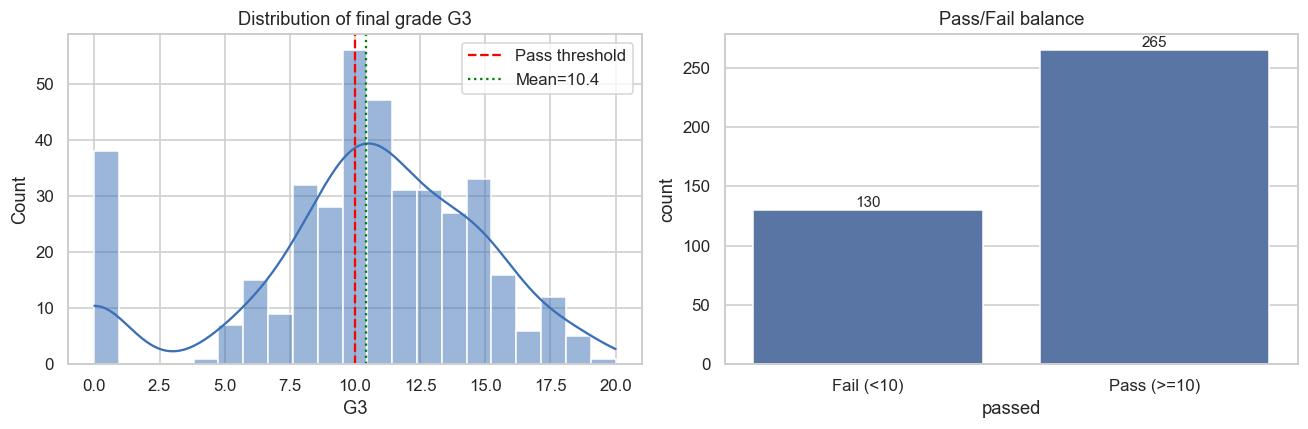

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.G3, bins=21, kde=True, ax=ax[0], color="#3b6fb6")
ax[0].axvline(10, color="red", ls="--", label="Pass threshold")
ax[0].axvline(df.G3.mean(), color="green", ls=":", label=f"Mean={df.G3.mean():.1f}")
ax[0].set_title("Distribution of final grade G3"); ax[0].legend()
sns.countplot(x="passed", data=df, ax=ax[1])
ax[1].set_xticklabels(["Fail (<10)", "Pass (>=10)"]); ax[1].set_title("Pass/Fail balance")
for p in ax[1].patches:
    ax[1].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom")
plt.tight_layout(); plt.show()

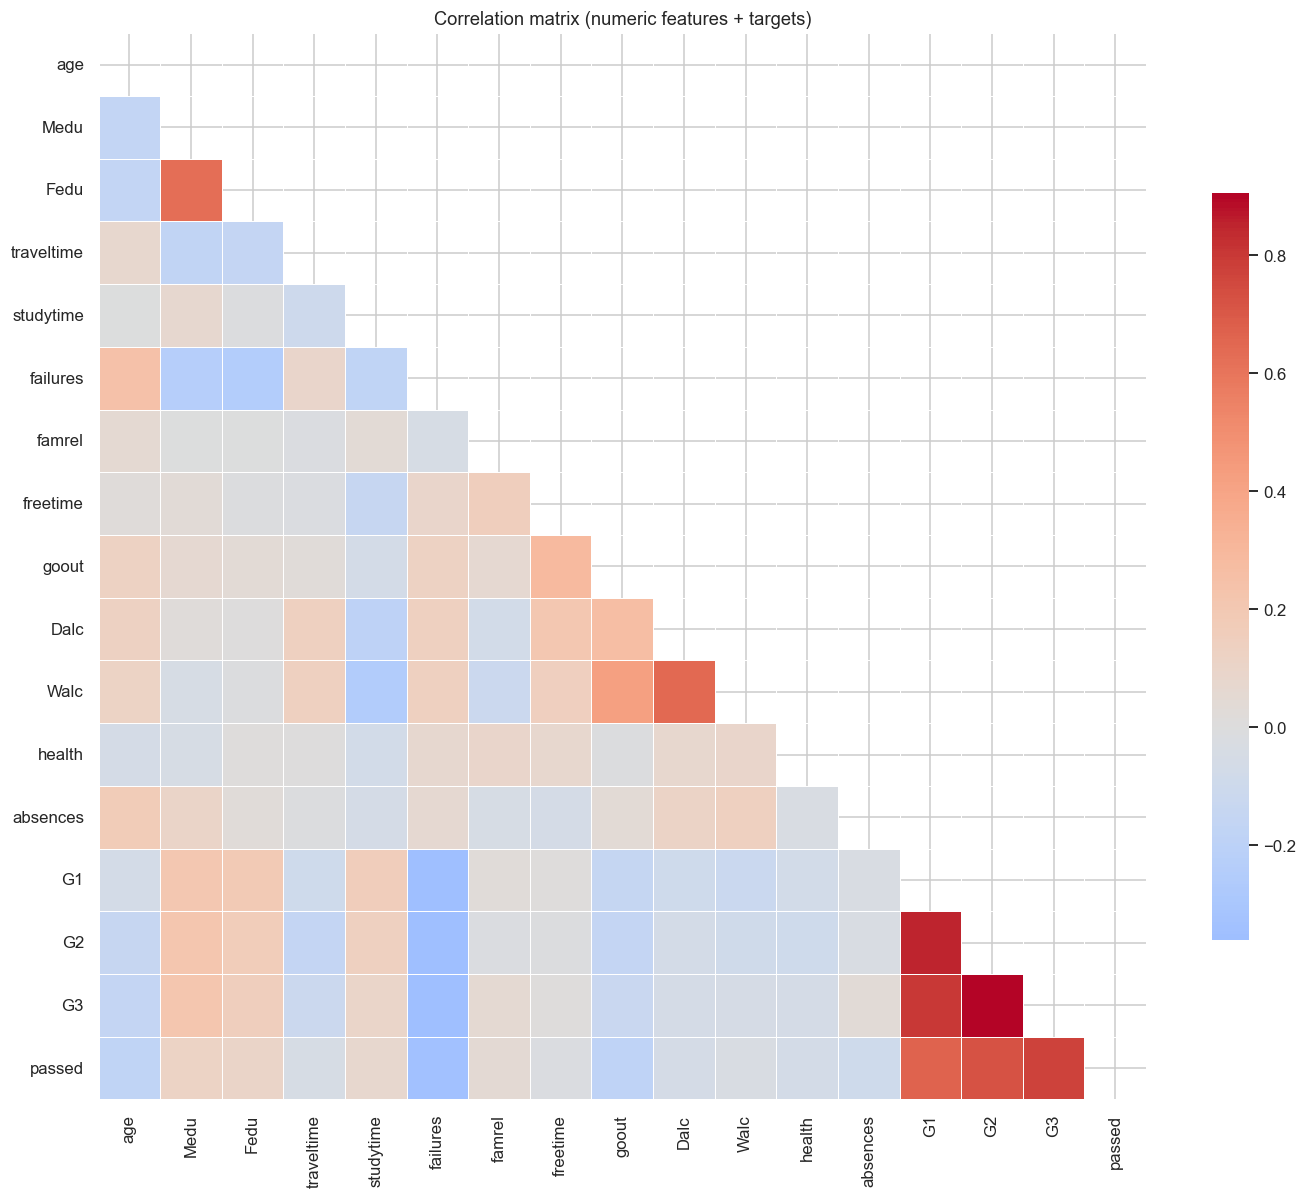

In [16]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, linewidths=.4,
            cbar_kws={"shrink": .7})
plt.title("Correlation matrix (numeric features + targets)")
plt.tight_layout(); plt.show()

In [17]:
# Rank numeric features by correlation with G3
g3_corr = corr["G3"].drop("G3").sort_values(ascending=False)
print("Correlation with G3 (sorted):")
print(g3_corr.round(3))

Correlation with G3 (sorted):
G2            0.905
G1            0.801
passed        0.770
Medu          0.217
Fedu          0.152
studytime     0.098
famrel        0.051
absences      0.034
freetime      0.011
Walc         -0.052
Dalc         -0.055
health       -0.061
traveltime   -0.117
goout        -0.133
age          -0.162
failures     -0.360
Name: G3, dtype: float64


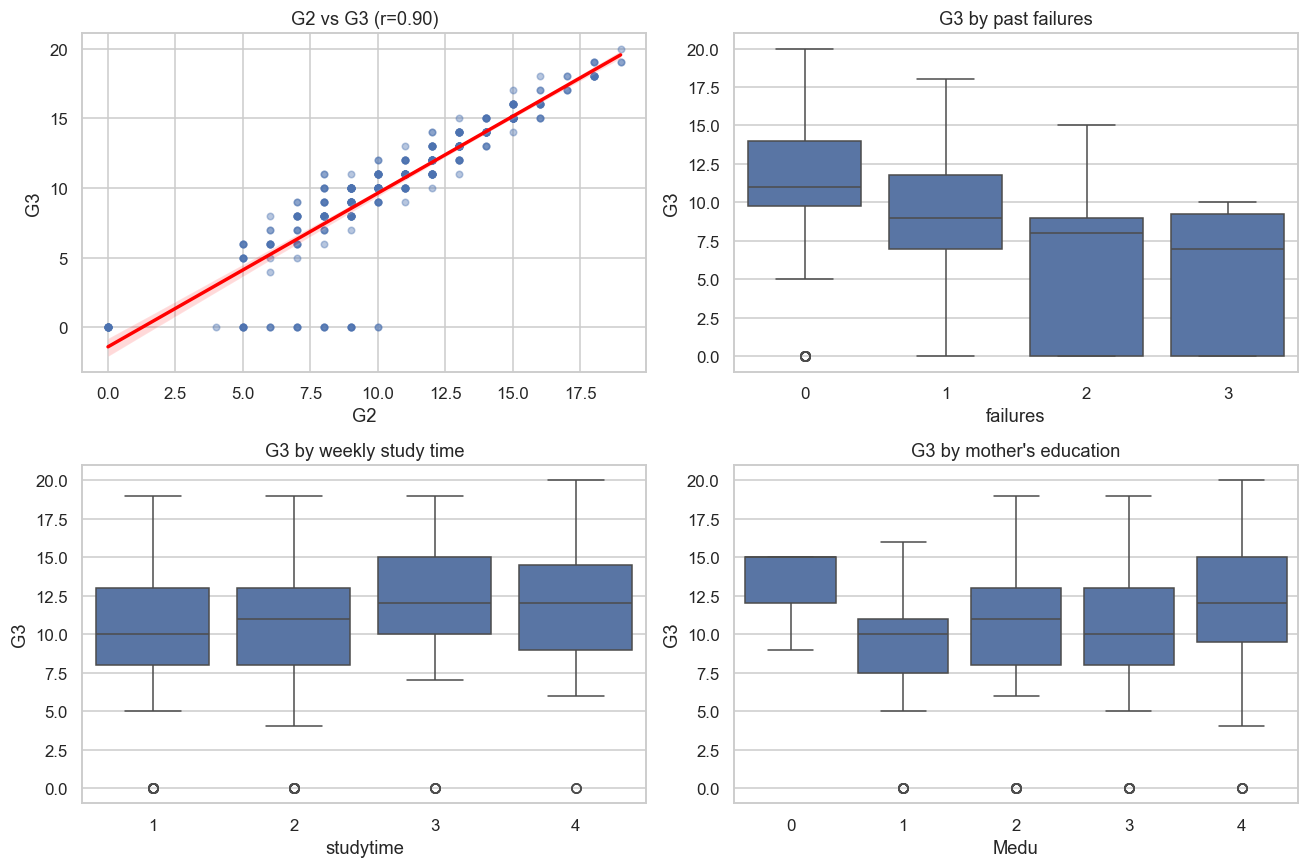

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
sns.regplot(x="G2", y="G3", data=df, ax=ax[0,0],
            scatter_kws={"alpha":.4,"s":18}, line_kws={"color":"red"})
ax[0,0].set_title(f"G2 vs G3 (r={df.G2.corr(df.G3):.2f})")
sns.boxplot(x="failures", y="G3", data=df, ax=ax[0,1]); ax[0,1].set_title("G3 by past failures")
sns.boxplot(x="studytime", y="G3", data=df, ax=ax[1,0]); ax[1,0].set_title("G3 by weekly study time")
sns.boxplot(x="Medu", y="G3", data=df, ax=ax[1,1]); ax[1,1].set_title("G3 by mother's education")
plt.tight_layout(); plt.show()

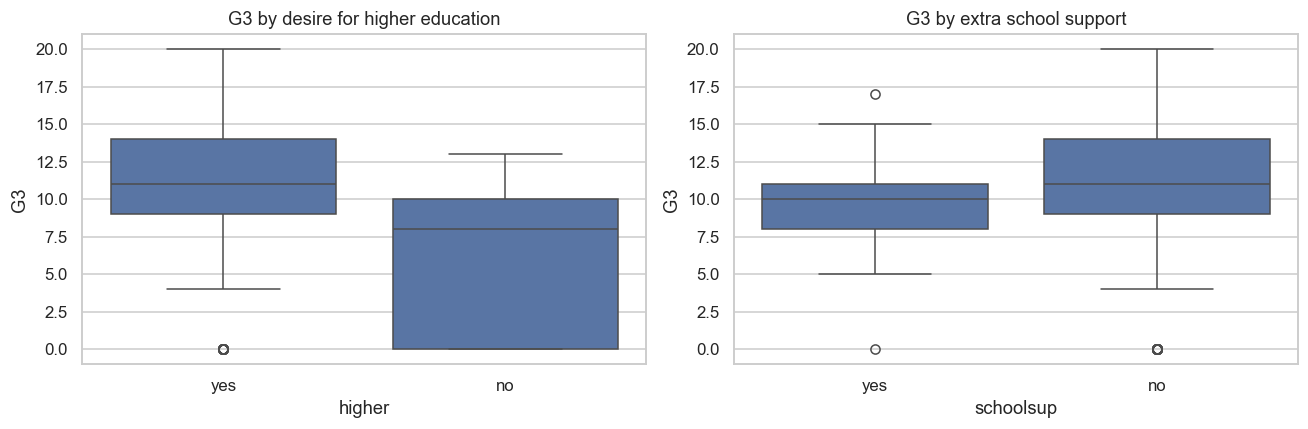

Mean G3 — wants higher ed: 10.61 | does not: 6.8


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="higher", y="G3", data=df, ax=ax[0]); ax[0].set_title("G3 by desire for higher education")
sns.boxplot(x="schoolsup", y="G3", data=df, ax=ax[1]); ax[1].set_title("G3 by extra school support")
plt.tight_layout(); plt.show()
print("Mean G3 — wants higher ed:", round(df[df.higher=='yes'].G3.mean(),2),
      "| does not:", round(df[df.higher=='no'].G3.mean(),2))

absences  IQR=[-12.0,20.0]  outliers=15  max=75
age       IQR=[13.0,21.0]  outliers=1  max=22
G3        IQR=[-1.0,23.0]  outliers=0  max=20


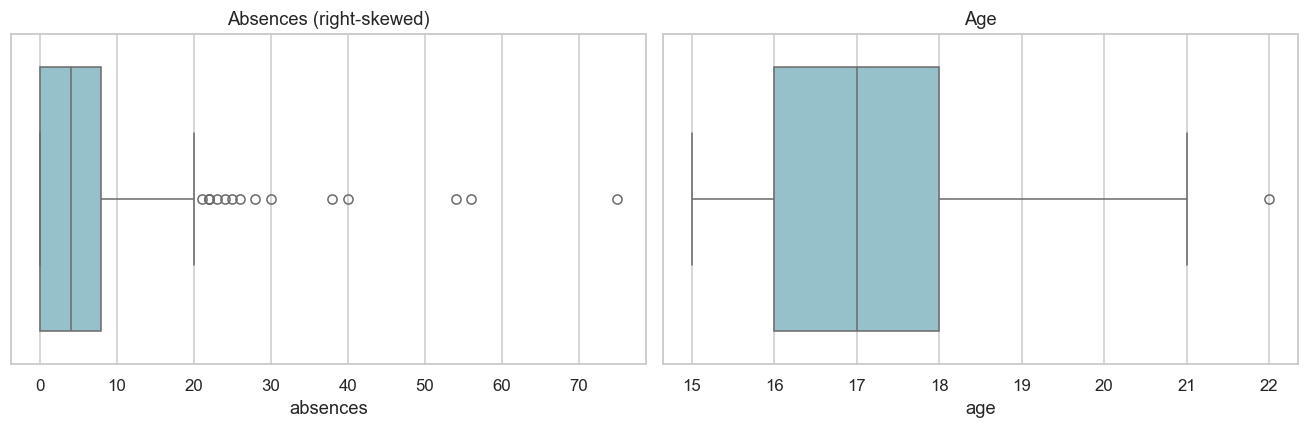

In [20]:
for col in ["absences", "age", "G3"]:
    q1, q3 = df[col].quantile([.25, .75]); iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    print(f"{col:9s} IQR=[{lb:.1f},{ub:.1f}]  outliers={n_out}  max={df[col].max()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df.absences, ax=ax[0], color="#8ec7d2"); ax[0].set_title("Absences (right-skewed)")
sns.boxplot(x=df.age, ax=ax[1], color="#8ec7d2"); ax[1].set_title("Age")
plt.tight_layout(); plt.show()

In [21]:
data = df.copy()

# Total alcohol consumption (weekday + weekend) — single behavioural index
data["alc_total"]        = data["Dalc"] + data["Walc"]
# Household education level (average of both parents)
data["parent_edu"]       = (data["Medu"] + data["Fedu"]) / 2
# Effort relative to academic history: high study time with no failures => strong signal
data["study_fail_ratio"] = data["studytime"] / (data["failures"] + 1)
# Breadth of support a student receives
data["support_count"]    = (data[["schoolsup","famsup","paid"]] == "yes").sum(axis=1)
# Combined social/leisure load
data["social"]           = data["goout"] + data["freetime"]

engineered = ["alc_total","parent_edu","study_fail_ratio","support_count","social"]
data[engineered].describe().round(2)

,alc_total,parent_edu,study_fail_ratio,support_count,social
count,395.00,395.00,395.00,395.00,395.00
mean,3.77,2.64,1.82,1.20,6.34
std,1.98,0.98,0.96,0.88,1.69
min,2.00,0.50,0.25,0.00,2.00
25%,2.00,2.00,1.00,0.00,5.00
50%,3.00,2.50,2.00,1.00,6.00
75%,5.00,3.50,2.00,2.00,8.00
max,10.00,4.00,4.00,3.00,10.00


In [22]:

binary_yn = ["schoolsup","famsup","paid","activities","nursery","higher","internet","romantic"]
for c in binary_yn:
    data[c] = (data[c] == "yes").astype(int)
data["sex"]     = (data["sex"]     == "M").astype(int)    # 1 = Male
data["address"] = (data["address"] == "U").astype(int)    # 1 = Urban
data["famsize"] = (data["famsize"] == "LE3").astype(int)  # 1 = <=3 members
data["Pstatus"] = (data["Pstatus"] == "T").astype(int)    # 1 = parents together
data["school"]  = (data["school"]  == "GP").astype(int)   # 1 = Gabriel Pereira

# True nominal columns handled later inside the ColumnTransformer (one-hot)
nominal = ["Mjob","Fjob","reason","guardian"]
print("Binary-encoded:", binary_yn + ["sex","address","famsize","Pstatus","school"])
print("One-hot (in pipeline):", nominal)

Binary-encoded: ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'sex', 'address', 'famsize', 'Pstatus', 'school']
One-hot (in pipeline): ['Mjob', 'Fjob', 'reason', 'guardian']


In [23]:
def build_Xy(frame, drop_periods=False):
    """Return feature matrix X (optionally without the leaky period grades G1,G2)."""
    X = frame.drop(columns=["G3", "passed"])
    if drop_periods:
        X = X.drop(columns=["G1", "G2"])
    return X

def make_preprocessor(X, scale=True):
    """ColumnTransformer: median-impute + (optional) scale numerics;
       mode-impute + one-hot encode the nominal columns."""
    nom = [c for c in nominal if c in X.columns]
    num = [c for c in X.columns if c not in nom]
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), nom),
    ])

X_full = build_Xy(data, drop_periods=False)
y_reg  = data["G3"].values            # regression target
y_clf  = data["passed"].values        # classification target
print("Feature matrix:", X_full.shape)

Feature matrix: (395, 37)


In [24]:

X_tr, X_tmp, yreg_tr, yreg_tmp, yclf_tr, yclf_tmp = train_test_split(
    X_full, y_reg, y_clf, test_size=0.40, random_state=RANDOM_STATE, stratify=y_clf)
X_val, X_te, yreg_val, yreg_te, yclf_val, yclf_te = train_test_split(
    X_tmp, yreg_tmp, yclf_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=yclf_tmp)


X_trval   = pd.concat([X_tr, X_val])
yreg_trval = np.concatenate([yreg_tr, yreg_val])
yclf_trval = np.concatenate([yclf_tr, yclf_val])

print(f"train={len(X_tr)}  val={len(X_val)}  test={len(X_te)}")
print(f"pass-rate  train={yclf_tr.mean():.2f}  val={yclf_val.mean():.2f}  test={yclf_te.mean():.2f}")

train=237  val=79  test=79
pass-rate  train=0.67  val=0.67  test=0.67


In [25]:
def reg_metrics(y, p):
    return {"MAE":  mean_absolute_error(y, p),
            "RMSE": np.sqrt(mean_squared_error(y, p)),
            "R2":   r2_score(y, p)}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_defs = {
 "Linear Regression": (LinearRegression(), {}, True),
 "Random Forest Regressor": (
     RandomForestRegressor(random_state=RANDOM_STATE),
     {"model__n_estimators":[200,400], "model__max_depth":[None,8,14],
      "model__min_samples_leaf":[1,2,4]}, False),
 "Gradient Boosting Regressor": (
     GradientBoostingRegressor(random_state=RANDOM_STATE),
     {"model__n_estimators":[200,400], "model__learning_rate":[0.03,0.05,0.1],
      "model__max_depth":[2,3]}, False),
}

reg_results, reg_best = {}, {}
for name, (est, grid, scale) in reg_defs.items():
    pipe = Pipeline([("prep", make_preprocessor(X_tr, scale=scale)), ("model", est)])
    if grid:
        gs = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error",
                          cv=cv, n_jobs=-1)
        gs.fit(X_tr, yreg_tr); best, bp = gs.best_estimator_, gs.best_params_
    else:
        pipe.fit(X_tr, yreg_tr); best, bp = pipe, {}
    val_m = reg_metrics(yreg_val, best.predict(X_val))
    reg_results[name] = {"val": val_m, "best_params": bp}; reg_best[name] = best
    print(f"{name:30s} VAL  MAE={val_m['MAE']:.3f} RMSE={val_m['RMSE']:.3f} "
          f"R2={val_m['R2']:.3f}  params={bp}")

Linear Regression              VAL  MAE=1.251 RMSE=1.956 R2=0.779  params={}
Random Forest Regressor        VAL  MAE=0.944 RMSE=1.548 R2=0.861  params={'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}
Gradient Boosting Regressor    VAL  MAE=1.033 RMSE=1.616 R2=0.849  params={'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 400}


In [26]:
best_reg_name = min(reg_results, key=lambda k: reg_results[k]["val"]["RMSE"])
print("Selected on validation RMSE ->", best_reg_name, "\n")

reg_table = {}
for name, (est, grid, scale) in reg_defs.items():
    params = {k.replace("model__",""): v for k,v in reg_results[name]["best_params"].items()}
    final = Pipeline([("prep", make_preprocessor(X_trval, scale=scale)),
                      ("model", est.__class__(**{**est.get_params(), **params}))])
    final.fit(X_trval, yreg_trval)
    test_m = reg_metrics(yreg_te, final.predict(X_te))
    reg_table[name] = {"val": reg_results[name]["val"], "test": test_m}
    if name == best_reg_name:
        final_reg, reg_test_pred = final, final.predict(X_te)

reg_cmp = pd.DataFrame({n: {**{f"val_{k}":v for k,v in d['val'].items()},
                            **{f"test_{k}":v for k,v in d['test'].items()}}
                        for n,d in reg_table.items()}).T
reg_cmp.round(3)

Selected on validation RMSE -> Random Forest Regressor 



,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
Linear Regression,1.251,1.956,0.779,1.736,2.341,0.744
Random Forest Regressor,0.944,1.548,0.861,1.196,1.797,0.849
Gradient Boosting Regressor,1.033,1.616,0.849,1.227,1.747,0.857


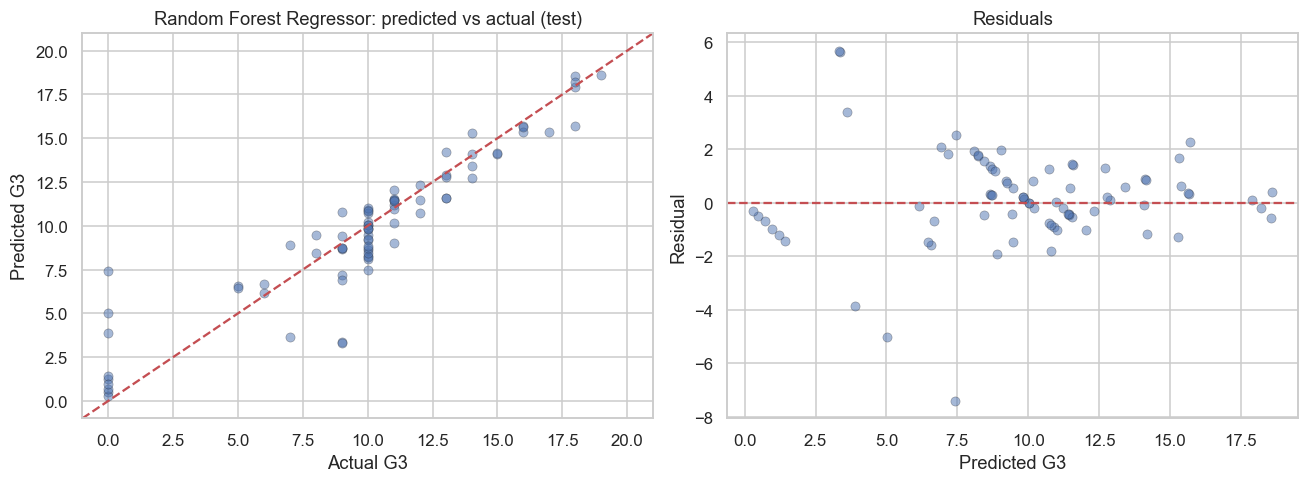

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(yreg_te, reg_test_pred, alpha=.5, edgecolor="k", linewidth=.3)
ax[0].plot([-1,21],[-1,21],"r--"); ax[0].set_xlim(-1,21); ax[0].set_ylim(-1,21)
ax[0].set_xlabel("Actual G3"); ax[0].set_ylabel("Predicted G3")
ax[0].set_title(f"{best_reg_name}: predicted vs actual (test)")
resid = yreg_te - reg_test_pred
ax[1].scatter(reg_test_pred, resid, alpha=.5, edgecolor="k", linewidth=.3)
ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("Predicted G3"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

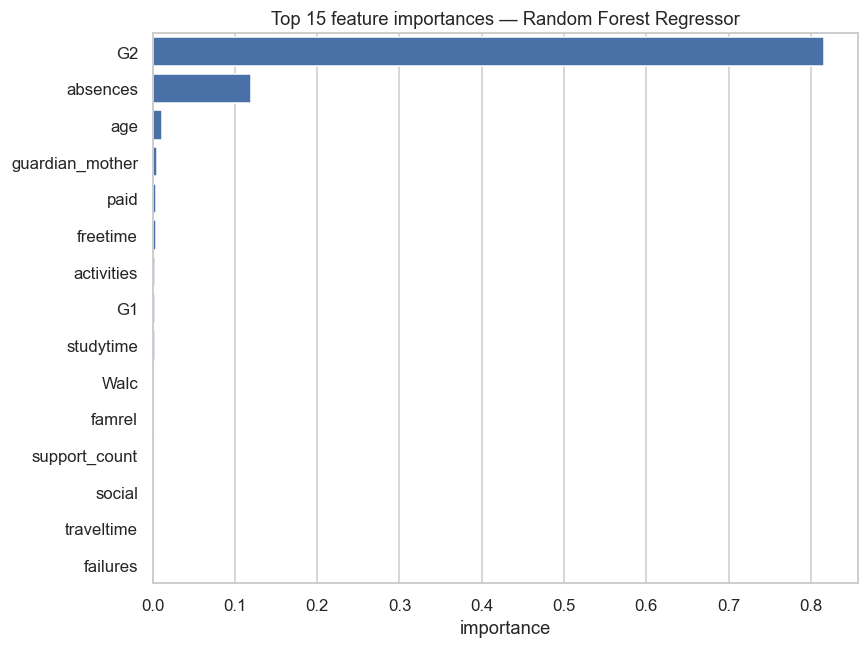

In [28]:

model = final_reg.named_steps["model"]
feat_names = final_reg.named_steps["prep"].get_feature_names_out()
if hasattr(model, "feature_importances_"):
    imp = (pd.Series(model.feature_importances_, index=feat_names)
             .sort_values(ascending=False).head(15))
    plt.figure(figsize=(8,6))
    sns.barplot(x=imp.values, y=[i.replace("num__","").replace("cat__","") for i in imp.index],
                color="#3b6fb6")
    plt.title(f"Top 15 feature importances — {best_reg_name}"); plt.xlabel("importance")
    plt.tight_layout(); plt.show()

In [29]:
def clf_metrics(y, p, proba):
    return {"Accuracy":  accuracy_score(y, p),
            "Precision": precision_score(y, p),
            "Recall":    recall_score(y, p),
            "F1":        f1_score(y, p),
            "ROC_AUC":   roc_auc_score(y, proba)}

scv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

clf_defs = {
 "Logistic Regression": (
     LogisticRegression(max_iter=2000, class_weight="balanced"),
     {"model__C":[0.05,0.1,0.5,1.0,5.0]}, True),
 "Decision Tree": (
     DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
     {"model__max_depth":[3,4,5,7,None], "model__min_samples_leaf":[1,5,10,20]}, False),
 "Random Forest Classifier": (
     RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
     {"model__n_estimators":[200,400], "model__max_depth":[None,6,10],
      "model__min_samples_leaf":[1,2,4]}, False),
}

clf_results = {}
for name, (est, grid, scale) in clf_defs.items():
    pipe = Pipeline([("prep", make_preprocessor(X_tr, scale=scale)), ("model", est)])
    gs = GridSearchCV(pipe, grid, scoring="f1", cv=scv, n_jobs=-1)
    gs.fit(X_tr, yclf_tr); best = gs.best_estimator_
    m = clf_metrics(yclf_val, best.predict(X_val), best.predict_proba(X_val)[:,1])
    clf_results[name] = {"val": m, "best_params": gs.best_params_}
    print(f"{name:28s} VAL  acc={m['Accuracy']:.3f} prec={m['Precision']:.3f} "
          f"rec={m['Recall']:.3f} f1={m['F1']:.3f} auc={m['ROC_AUC']:.3f}  {gs.best_params_}")

Logistic Regression          VAL  acc=0.911 prec=0.942 rec=0.925 f1=0.933 auc=0.973  {'model__C': 5.0}
Decision Tree                VAL  acc=0.924 prec=0.961 rec=0.925 f1=0.942 auc=0.972  {'model__max_depth': 3, 'model__min_samples_leaf': 20}
Random Forest Classifier     VAL  acc=0.924 prec=0.943 rec=0.943 f1=0.943 auc=0.960  {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


In [30]:
best_clf_name = max(clf_results, key=lambda k: clf_results[k]["val"]["F1"])
print("Selected on validation F1 ->", best_clf_name, "\n")

clf_table, roc_data = {}, {}
for name, (est, grid, scale) in clf_defs.items():
    params = {k.replace("model__",""): v for k,v in clf_results[name]["best_params"].items()}
    final = Pipeline([("prep", make_preprocessor(X_trval, scale=scale)),
                      ("model", est.__class__(**{**est.get_params(), **params}))])
    final.fit(X_trval, yclf_trval)
    proba = final.predict_proba(X_te)[:,1]; pred = final.predict(X_te)
    m = clf_metrics(yclf_te, pred, proba)
    clf_table[name] = {"val": clf_results[name]["val"], "test": m}
    fpr, tpr, _ = roc_curve(yclf_te, proba); roc_data[name] = (fpr, tpr, m["ROC_AUC"])
    if name == best_clf_name:
        best_pred = pred

clf_cmp = pd.DataFrame({n: {**{f"val_{k}":v for k,v in d['val'].items()},
                            **{f"test_{k}":v for k,v in d['test'].items()}}
                        for n,d in clf_table.items()}).T
clf_cmp.round(3)

Selected on validation F1 -> Random Forest Classifier 



,val_Accuracy,val_Precision,val_Recall,val_F1,val_ROC_AUC,test_Accuracy,test_Precision,test_Recall,test_F1,test_ROC_AUC
Logistic Regression,0.911,0.942,0.925,0.933,0.973,0.861,0.957,0.830,0.889,0.936
Decision Tree,0.924,0.961,0.925,0.942,0.972,0.873,0.957,0.849,0.900,0.932
Random Forest Classifier,0.924,0.943,0.943,0.943,0.960,0.848,0.918,0.849,0.882,0.943


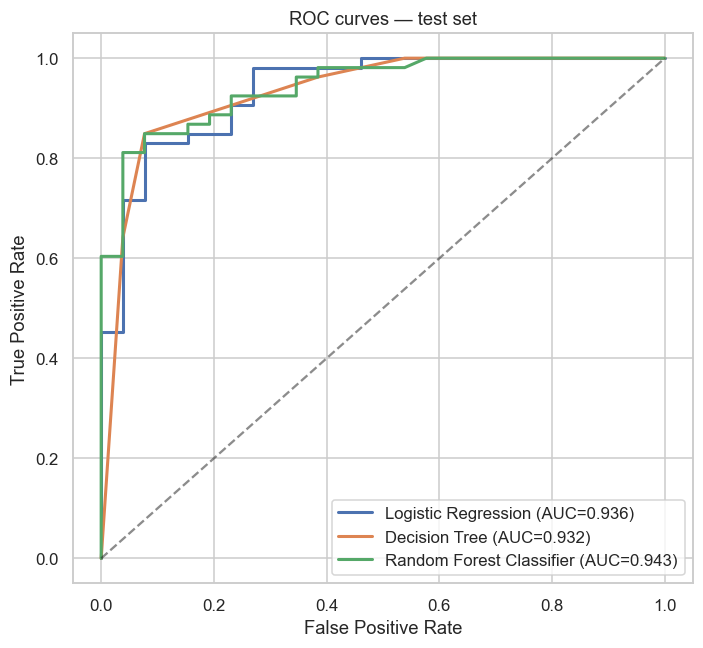

In [31]:
plt.figure(figsize=(6.5,6))
for name,(fpr,tpr,auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--",alpha=.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves — test set"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

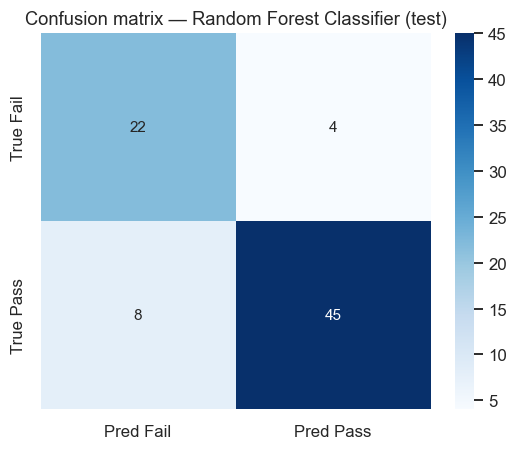

              precision    recall  f1-score   support

        Fail       0.73      0.85      0.79        26
        Pass       0.92      0.85      0.88        53

    accuracy                           0.85        79
   macro avg       0.83      0.85      0.83        79
weighted avg       0.86      0.85      0.85        79



In [32]:
cm = confusion_matrix(yclf_te, best_pred)
plt.figure(figsize=(5,4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fail","Pred Pass"], yticklabels=["True Fail","True Pass"])
plt.title(f"Confusion matrix — {best_clf_name} (test)"); plt.tight_layout(); plt.show()

print(classification_report(yclf_te, best_pred, target_names=["Fail","Pass"]))

In [33]:
print("FINAL REGRESSION MODEL :", best_reg_name)
print(reg_cmp[["test_MAE","test_RMSE","test_R2"]].round(3), "\n")
print("FINAL CLASSIFICATION MODEL :", best_clf_name)
print(clf_cmp[["test_Accuracy","test_Precision","test_Recall","test_F1","test_ROC_AUC"]].round(3))

FINAL REGRESSION MODEL : Random Forest Regressor
                             test_MAE  test_RMSE  test_R2
Linear Regression               1.736      2.341    0.744
Random Forest Regressor         1.196      1.797    0.849
Gradient Boosting Regressor     1.227      1.747    0.857 

FINAL CLASSIFICATION MODEL : Random Forest Classifier
                          test_Accuracy  test_Precision  test_Recall  test_F1  \
Logistic Regression               0.861           0.957        0.830    0.889   
Decision Tree                     0.873           0.957        0.849    0.900   
Random Forest Classifier          0.848           0.918        0.849    0.882   

                          test_ROC_AUC  
Logistic Regression              0.936  
Decision Tree                    0.932  
Random Forest Classifier         0.943  


In [34]:
X_ew = build_Xy(data, drop_periods=True)
Xew_tr, Xew_tmp, yr_tr, yr_tmp, yc_tr, yc_tmp = train_test_split(
    X_ew, y_reg, y_clf, test_size=0.40, random_state=RANDOM_STATE, stratify=y_clf)
Xew_val, Xew_te, yr_val, yr_te, yc_val, yc_te = train_test_split(
    Xew_tmp, yr_tmp, yc_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=yc_tmp)
Xew_trval = pd.concat([Xew_tr, Xew_val])
yr_trval = np.concatenate([yr_tr, yr_val]); yc_trval = np.concatenate([yc_tr, yc_val])

ew_reg = Pipeline([("prep", make_preprocessor(Xew_trval, scale=False)),
                   ("model", GradientBoostingRegressor(random_state=RANDOM_STATE,
                             n_estimators=400, learning_rate=0.03, max_depth=2))])
ew_reg.fit(Xew_trval, yr_trval)
print("Early-warning regression :", {k: round(v,3) for k,v in
      reg_metrics(yr_te, ew_reg.predict(Xew_te)).items()})

ew_clf = Pipeline([("prep", make_preprocessor(Xew_trval, scale=False)),
                   ("model", RandomForestClassifier(random_state=RANDOM_STATE,
                             n_estimators=400, class_weight="balanced"))])
ew_clf.fit(Xew_trval, yc_trval)
proba = ew_clf.predict_proba(Xew_te)[:,1]
print("Early-warning classifier :", {k: round(v,3) for k,v in
      clf_metrics(yc_te, ew_clf.predict(Xew_te), proba).items()})

Early-warning regression : {'MAE': 3.015, 'RMSE': 3.94, 'R2': 0.275}
Early-warning classifier : {'Accuracy': 0.772, 'Precision': 0.769, 'Recall': 0.943, 'F1': 0.847, 'ROC_AUC': 0.748}


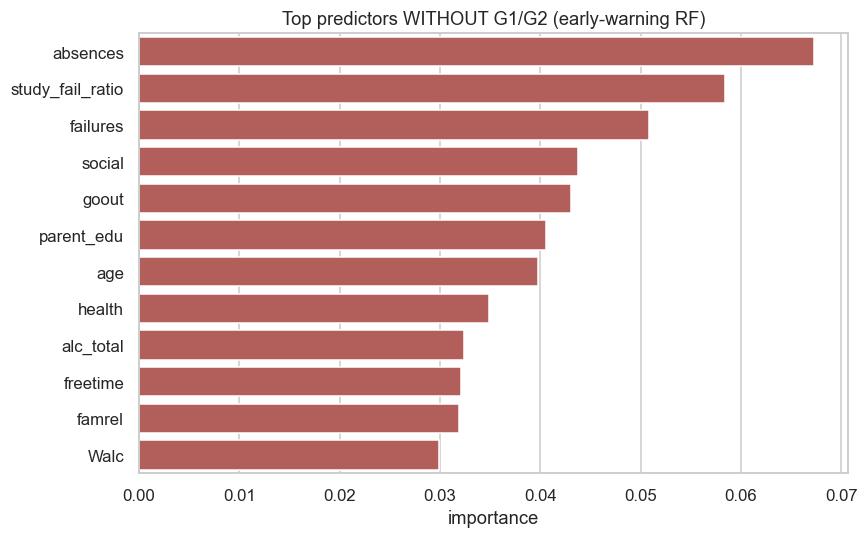

In [35]:
fn = ew_clf.named_steps["prep"].get_feature_names_out()
imp = (pd.Series(ew_clf.named_steps["model"].feature_importances_, index=fn)
         .sort_values(ascending=False).head(12))
plt.figure(figsize=(8,5))
sns.barplot(x=imp.values, y=[i.replace("num__","").replace("cat__","") for i in imp.index],
            color="#c0504d")
plt.title("Top predictors WITHOUT G1/G2 (early-warning RF)"); plt.xlabel("importance")
plt.tight_layout(); plt.show()